<a href="https://colab.research.google.com/github/danghuy11/OAI/blob/main/01-convolution/convolution3-training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!test -f lena.jpg || wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
from google.colab import files
import os
print('lena-sobel.txt')
while not os.path.exists('lena-sobel.txt'):
    files.upload()

--2026-06-07 16:56:14--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91814 (90K) [image/jpeg]
Saving to: ‘lena.jpg’

lena.jpg            100%[===================>]  89.66K  --.-KB/s    in 0.009s  

2026-06-07 16:56:14 (9.46 MB/s) - ‘lena.jpg’ saved [91814/91814]

lena-sobel.txt


Saving lena-sobel.txt to lena-sobel.txt


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [3]:
# load samples (single image provides many samples for edge detection)
sample_inp = cv2.imread('lena.jpg',cv2.IMREAD_GRAYSCALE)
sample_out = np.loadtxt('lena-sobel.txt', dtype=np.float32)
rows,cols = sample_inp.shape
samples_inp = torch.from_numpy(sample_inp).float().unsqueeze(0).unsqueeze(0)
samples_out = torch.from_numpy(sample_out).float().unsqueeze(0).unsqueeze(0)
print(samples_inp.shape)
print(samples_out.shape)

torch.Size([1, 1, 512, 512])
torch.Size([1, 1, 512, 512])


In [4]:
# define the model
class SobelFilter(nn.Module):
    # initialization
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1,1,(3,3),bias=False,padding=1)
    # forward
    def forward(self, x):
        return self.conv(x)

In [5]:
model = SobelFilter()

In [6]:
# Define loss function
loss_function = nn.MSELoss(reduction='sum')

In [7]:
# Define optimizer
optimizer = optim.Adam(model.parameters())

In [8]:
# Training
num_epochs = 12500

In [9]:
for t in range(num_epochs):
    # Forward pass
    out = model(samples_inp)
    loss = loss_function(out, samples_out)
    if t % 100 == 0:
        print(t, loss.item())
    # Reset gradients
    optimizer.zero_grad()
    # Backward pass
    loss.backward()
    # Update model parameters (weights)
    optimizer.step()

0 4282113024.0
100 1576880896.0
200 1489493248.0
300 1456365312.0
400 1417329536.0
500 1373428992.0
600 1325495552.0
700 1274234624.0
800 1220274560.0
900 1164190592.0
1000 1106516736.0
1100 1047752768.0
1200 988367552.0
1300 928800512.0
1400 869461504.0
1500 810731264.0
1600 752959744.0
1700 696465920.0
1800 641538176.0
1900 588431936.0
2000 537370432.0
2100 488544736.0
2200 442112928.0
2300 398201248.0
2400 356904800.0
2500 318287872.0
2600 282385664.0
2700 249205296.0
2800 218727552.0
2900 190908736.0
3000 165682368.0
3100 142961776.0
3200 122641960.0
3300 104602752.0
3400 88710432.0
3500 74821264.0
3600 62783768.0
3700 52441212.0
3800 43635028.0
3900 36206944.0
4000 30001456.0
4100 24868328.0
4200 20664548.0
4300 17255980.0
4400 14518942.0
4500 12341102.0
4600 10622263.0
4700 9274508.0
4800 8222054.0
4900 7400865.5
5000 6757852.0
5100 6249836.5
5200 5842519.0
5300 5509201.0
5400 5229568.5
5500 4988558.5
5600 4775249.5
5700 4581939.5
5800 4403315.5
5900 4235809.5
6000 4077082.0
6100

In [10]:
# Print weighs
for param in model.parameters():
    print(param.data)

tensor([[[[-1.0125,  0.0113,  0.9993],
          [-1.9769, -0.0226,  2.0033],
          [-1.0130,  0.0144,  0.9967]]]])


In [11]:
output_images = model(samples_inp)

In [12]:
output_image = output_images[0]
output_image = output_image.squeeze(0)
output_image = output_image.detach().numpy()
print(output_image.shape)
print(np.amax(output_image))
print(np.amin(output_image))

(512, 512)
689.381
-857.8317


In [13]:
output_image = abs(output_image);
output_image = cv2.normalize(output_image,None,0,255,cv2.NORM_MINMAX)
output_image = np.uint8(output_image)
cv2.imwrite('lena-sobel2.jpg',output_image)

True

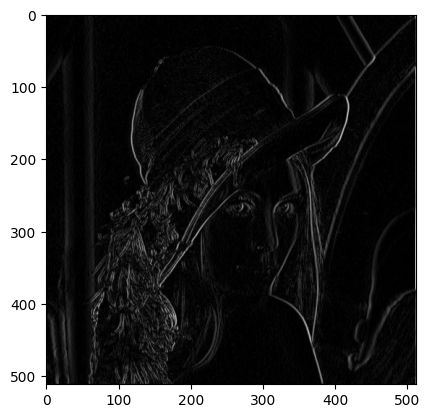

In [14]:
plt.imshow(output_image, cmap='gray')
plt.show()

In [15]:
# save the model
torch.save(model.state_dict(), 'sobel.pth') # weights only

In [16]:
from google.colab import files
files.download('lena-sobel2.jpg')
files.download('sobel.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>